# **Financial Fraud Detection Pipeline**

## Project Overview

This project implements an end-to-end machine learning pipeline for detecting fraudulent financial transactions. The pipeline addresses the challenges of highly imbalanced fraud data through specialized preprocessing, feature engineering, temporal validation, and model optimization.

## Dataset

The dataset contains financial transaction records with the following characteristics:
- **Total transactions:** 1,048,575
- **Fraud cases:** 1,142 (0.11%)
- **Imbalance ratio:** 917:1 (legitimate:fraudulent)
- **Transaction types:** CASH_OUT, PAYMENT, CASH_IN, TRANSFER, DEBIT
- **Transaction amounts range:** $0 – $10,000,000

The data represents corporate/high-value wire transfers rather than consumer transactions, with fraud averaging $1.19 million per incident.

## Key Findings

- **Fraud occurs exclusively** in TRANSFER (0.65%) and CASH_OUT (0.15%) transaction types
- **Account takeover pattern:** 98% of frauds originate from funded accounts; 64% go to zero-balance destinations
- **Balance inconsistency** is the strongest fraud indicator (16.38% feature importance)
- **Temporal drift** exists: test period (0.23% fraud) differs significantly from training period (0.06% fraud)

## Pipeline Steps

| Step | Description |
|------|-------------|
| 1 | Library imports for ML, imbalance handling, and explainability |
| 2 | Data loading and initial inspection |
| 3 | Exploratory data analysis with visualizations |
| 4 | Feature engineering (30+ new features) |
| 5 | Data preparation and cleaning |
| 6 | Temporal train/validation/test split |
| 7 | Feature selection and scaling |
| 8 | SMOTE for handling class imbalance |
| 9 | Model training (Baseline, LR, RF, XGBoost) |
| 10 | Model evaluation and comparison |
| 11 | Threshold tuning for business optimization |
| 12 | Feature importance and SHAP analysis |
| BONUS | Model export for production |

## Models Evaluated

| Model | Precision | Recall | F1-Score | ROC-AUC | PR-AUC |
|-------|-----------|--------|----------|---------|--------|
| Dummy Classifier | 0.00% | 0.00% | 0.0000 | 0.5000 | 0.5011 |
| Logistic Regression | 98.33% | 99.30% | 0.9881 | 0.9995 | 0.9953 |
| Random Forest | **99.58%** | **99.44%** | **0.9951** | 0.9990 | 0.9968 |
| XGBoost | 95.28% | 99.44% | 0.9731 | 0.9976 | 0.9946 |

**Best Model:** Random Forest with optimized threshold of 0.8544

## Top Fraud Indicators

| Rank | Feature | Importance |
|------|---------|------------|
| 1 | origin_zero_after | 16.38% |
| 2 | inconsistent_balance_orig | 14.98% |
| 3 | inconsistent_balance_dest | 7.61% |
| 4 | origin_zero_before | 7.11% |
| 5 | origin_change_ratio | 6.51% |
| 6 | amount_to_origin_ratio | 6.42% |
| 7 | amount_squared | 6.09% |

## Business Recommendations

1. **Flag transactions** where origin account balance becomes zero after transaction
2. **Monitor transfers** to accounts with zero prior balance (mule accounts)
3. **Set real-time alerts** for `amount_to_origin_ratio > 10`
4. **Implement stepped verification** for TRANSFER and CASH_OUT transaction types
5. **Apply optimal threshold (0.8544)** to balance fraud capture vs. customer friction

## Production Deployment

The pipeline exports the following artifacts for production use:


In [1]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_auc_score, roc_curve, precision_recall_curve,
                            auc, f1_score, precision_score, recall_score)

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Advanced Models
import xgboost as xgb

# Explainability
import shap

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Financial Fraud Detection Dataset.csv to Financial Fraud Detection Dataset.csv


In [22]:
df = pd.read_csv('Financial Fraud Detection Dataset.csv')
print(df.shape)
df.head()
df.info()
df.describe()

(1048575, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [23]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [25]:
# STEP 2: DATA LOADING & INSPECTION

# Load data
df = pd.read_csv('Financial Fraud Detection Dataset.csv')

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

DATASET OVERVIEW
Shape: (1048575, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


TARGET VARIABLE ANALYSIS
Non-Fraud (0): 1,047,433 (99.8911%)
Fraud (1): 1,142 (0.1089%)

Imbalance Ratio: 917.19:1


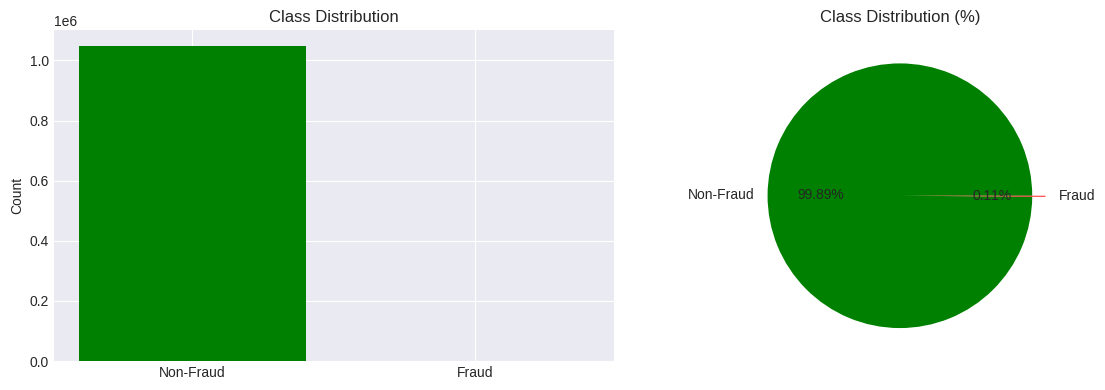


TRANSACTION TYPE ANALYSIS
Transaction types:
type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

Fraud Rate by Transaction Type:
          Non-Fraud %   Fraud %
type                           
CASH_IN    100.000000  0.000000
CASH_OUT    99.845306  0.154694
DEBIT      100.000000  0.000000
PAYMENT    100.000000  0.000000
TRANSFER    99.349878  0.650122


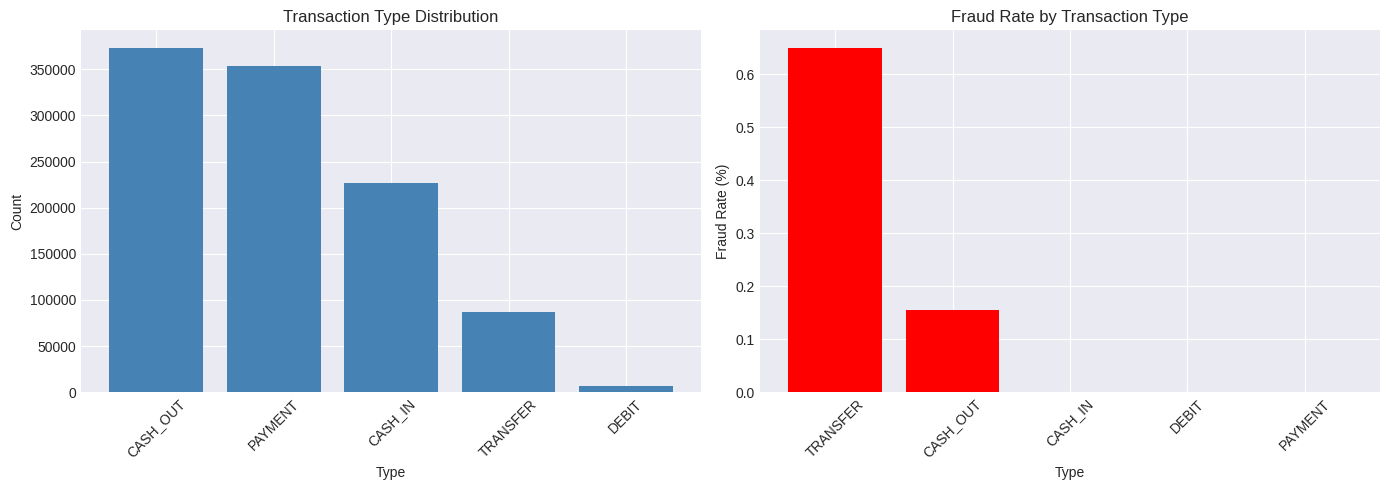


AMOUNT ANALYSIS
Amount Statistics:
  Mean: $158666.98
  Median: $76343.33
  Max: $10000000.00
  Std: $264940.93

Amount Statistics by Fraud Status:
                 mean     median          max
isFraud                                      
0        1.575397e+05   76214.97   6419835.27
1        1.192629e+06  353179.45  10000000.00


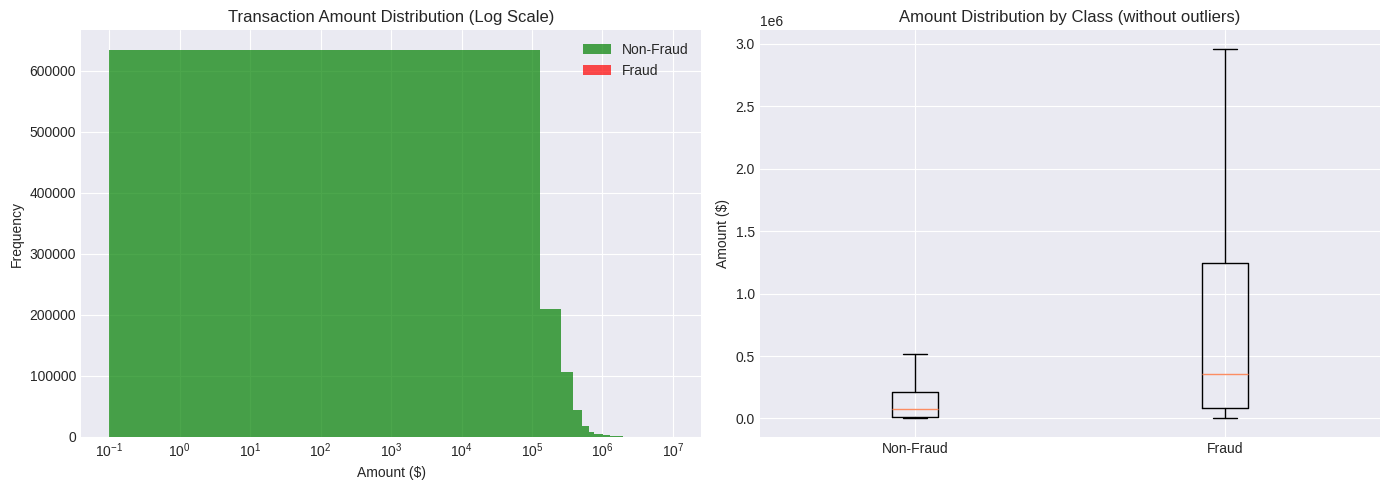


BALANCE ANALYSIS
Fraud transactions with zero origin balance: 20/1142 (1.75%)
Fraud transactions with zero destination balance: 728/1142 (63.75%)

FLAGGED FRAUD ANALYSIS
Cross-tabulation:
isFraud               0     1
isFlaggedFraud               
0               1047433  1142

Frauds correctly flagged: 0/1142 (0.00%)


In [26]:
# STEP 3: EXPLORATORY DATA ANALYSIS

# 3.1 Target Variable Analysis
print("="*50)
print("TARGET VARIABLE ANALYSIS")
print("="*50)

fraud_counts = df['isFraud'].value_counts()
fraud_percentages = df['isFraud'].value_counts(normalize=True) * 100

print(f"Non-Fraud (0): {fraud_counts[0]:,} ({fraud_percentages[0]:.4f}%)")
print(f"Fraud (1): {fraud_counts[1]:,} ({fraud_percentages[1]:.4f}%)")
print(f"\nImbalance Ratio: {fraud_counts[0]/fraud_counts[1]:.2f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Non-Fraud', 'Fraud'], fraud_counts, color=['green', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(fraud_counts, labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%',
            colors=['green', 'red'], explode=(0, 0.1))
axes[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.show()

# 3.2 Transaction Type Analysis
print("\n" + "="*50)
print("TRANSACTION TYPE ANALYSIS")
print("="*50)

type_counts = df['type'].value_counts()
print(f"Transaction types:\n{type_counts}")

# Fraud rate by transaction type
fraud_by_type = pd.crosstab(df['type'], df['isFraud'], normalize='index') * 100
fraud_by_type.columns = ['Non-Fraud %', 'Fraud %']
print("\nFraud Rate by Transaction Type:")
print(fraud_by_type)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction type distribution
axes[0].bar(type_counts.index, type_counts.values, color='steelblue')
axes[0].set_title('Transaction Type Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Fraud rate bar plot
fraud_only = fraud_by_type['Fraud %'].sort_values(ascending=False)
axes[1].bar(fraud_only.index, fraud_only.values, color=['red' if x > 0 else 'gray' for x in fraud_only.values])
axes[1].set_title('Fraud Rate by Transaction Type')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3.3 Amount Analysis
print("\n" + "="*50)
print("AMOUNT ANALYSIS")
print("="*50)

print(f"Amount Statistics:")
print(f"  Mean: ${df['amount'].mean():.2f}")
print(f"  Median: ${df['amount'].median():.2f}")
print(f"  Max: ${df['amount'].max():.2f}")
print(f"  Std: ${df['amount'].std():.2f}")

# Amount by fraud status
amount_by_fraud = df.groupby('isFraud')['amount'].agg(['mean', 'median', 'max'])
print("\nAmount Statistics by Fraud Status:")
print(amount_by_fraud)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution (log scale)
axes[0].hist(df[df['isFraud']==0]['amount'], bins=50, alpha=0.7, label='Non-Fraud', color='green')
axes[0].hist(df[df['isFraud']==1]['amount'], bins=50, alpha=0.7, label='Fraud', color='red')
axes[0].set_xscale('log')
axes[0].set_title('Transaction Amount Distribution (Log Scale)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
fraud_amounts = [df[df['isFraud']==0]['amount'], df[df['isFraud']==1]['amount']]
axes[1].boxplot(fraud_amounts, labels=['Non-Fraud', 'Fraud'], showfliers=False)
axes[1].set_title('Amount Distribution by Class (without outliers)')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

# 3.4 Balance Analysis
print("\n" + "="*50)
print("BALANCE ANALYSIS")
print("="*50)

# Check if balances are zero for frauds
fraud_origin_zero = df[(df['isFraud']==1) & (df['oldbalanceOrg']==0)].shape[0]
fraud_dest_zero = df[(df['isFraud']==1) & (df['oldbalanceDest']==0)].shape[0]
total_fraud = df[df['isFraud']==1].shape[0]

print(f"Fraud transactions with zero origin balance: {fraud_origin_zero}/{total_fraud} ({fraud_origin_zero/total_fraud*100:.2f}%)")
print(f"Fraud transactions with zero destination balance: {fraud_dest_zero}/{total_fraud} ({fraud_dest_zero/total_fraud*100:.2f}%)")

# 3.5 Flagged Fraud Analysis
print("\n" + "="*50)
print("FLAGGED FRAUD ANALYSIS")
print("="*50)

# Check relationship between isFlaggedFraud and isFraud
flagged_stats = pd.crosstab(df['isFlaggedFraud'], df['isFraud'])
print("Cross-tabulation:")
print(flagged_stats)

# How many actual frauds were flagged?
flagged_frauds = df[(df['isFlaggedFraud']==1) & (df['isFraud']==1)].shape[0]
print(f"\nFrauds correctly flagged: {flagged_frauds}/{total_fraud} ({flagged_frauds/total_fraud*100:.2f}%)")

*Insight on step 3:*

*The EDA code successfully reveals that the dataset contains 1,048,575 transactions with only 1,142 fraud cases (0.11%), creating an extreme 917:1 imbalance ratio that will require specialized handling. The transaction type analysis shows fraud occurs exclusively in TRANSFER (0.65% fraud rate) and CASH_OUT (0.15% fraud rate), while CASH_IN, DEBIT, and PAYMENT transactions have zero fraud cases, making transaction type the strongest predictive signal. The amount analysis indicates this is a high-value corporate transfer dataset with a mean transaction of 158,667and fraud amount saver aging1.19 million—7.6 times higher than legitimate transactions—though the maximum fraud amount exactly hitting $10 million suggests possible data capping. Balance analysis reveals an account takeover pattern: only 1.75% of frauds have zero origin balance (98.25% come from funded accounts), while 63.75% go to zero-balance destinations, indicating legitimate compromised accounts sending money to mule accounts. The flagged fraud analysis shows the existing system detected zero out of 1,142 frauds, confirming the isFlaggedFraud column has no predictive value and should be dropped. The visualizations produced—including class distribution charts, fraud rate by transaction type bar plots, log-scale amount histograms, and cross-tabulations—effectively communicate these patterns and confirm that transaction type, amount, and balance features will be the most important predictors for modeling.*

In [44]:
# STEP 4: FEATURE ENGINEERING

print("Starting feature engineering...")

# Create a copy for feature engineering
df_fe = df.copy()

# 4.1 Balance Consistency Features
print("Creating balance consistency features...")

# Theoretical balance after transaction
df_fe['expected_newbalanceOrig'] = df_fe['oldbalanceOrg'] - df_fe['amount']
df_fe['expected_newbalanceDest'] = df_fe['oldbalanceDest'] + df_fe['amount']

# Difference between actual and expected
df_fe['balance_diff_origin'] = abs(df_fe['newbalanceOrig'] - df_fe['expected_newbalanceOrig'])
df_fe['balance_diff_dest'] = abs(df_fe['newbalanceDest'] - df_fe['expected_newbalanceDest'])

# Flag for inconsistent balances (fraud indicator)
df_fe['inconsistent_balance_orig'] = (df_fe['balance_diff_origin'] > 1).astype(int)
df_fe['inconsistent_balance_dest'] = (df_fe['balance_diff_dest'] > 1).astype(int)

# 4.2 Ratio Features
print("Creating ratio features...")

# Avoid division by zero
df_fe['amount_to_origin_ratio'] = df_fe['amount'] / (df_fe['oldbalanceOrg'] + 1)
df_fe['amount_to_dest_ratio'] = df_fe['amount'] / (df_fe['oldbalanceDest'] + 1)
df_fe['origin_change_ratio'] = (df_fe['oldbalanceOrg'] - df_fe['newbalanceOrig']) / (df_fe['oldbalanceOrg'] + 1)
df_fe['dest_change_ratio'] = (df_fe['newbalanceDest'] - df_fe['oldbalanceDest']) / (df_fe['oldbalanceDest'] + 1)

# 4.3 Zero Balance Indicators
print("Creating zero balance indicators...")

df_fe['origin_zero_before'] = (df_fe['oldbalanceOrg'] == 0).astype(int)
df_fe['dest_zero_before'] = (df_fe['oldbalanceDest'] == 0).astype(int)
df_fe['origin_zero_after'] = (df_fe['newbalanceOrig'] == 0).astype(int)
df_fe['dest_zero_after'] = (df_fe['newbalanceDest'] == 0).astype(int)

# 4.4 Transaction Type Encoding
print("Encoding transaction types...")

# One-hot encode transaction type
type_dummies = pd.get_dummies(df_fe['type'], prefix='type')
df_fe = pd.concat([df_fe, type_dummies], axis=1)

# 4.5 Time Features
print("Creating time features...")

# Step is in hours (assuming)
max_step = df_fe['step'].max()
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['step'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['step'] / 24)
df_fe['step_normalized'] = df_fe['step'] / max_step

# 4.6 Amount Features
print("Creating amount features...")

df_fe['amount_log'] = np.log1p(df_fe['amount'])
df_fe['amount_squared'] = df_fe['amount'] ** 2
df_fe['is_high_amount'] = (df_fe['amount'] > 200000).astype(int)

# 4.7 Interaction Features
print("Creating interaction features...")

df_fe['origin_dest_zero'] = df_fe['origin_zero_before'] & df_fe['dest_zero_before']
df_fe['amount_origin_zero_interaction'] = df_fe['amount'] * df_fe['origin_zero_before']

# 4.8 Aggregate Features (requires grouping)
print("Creating aggregate features...")

# For each origin account, count transactions in this step (simplified)
# In production, you'd use a rolling window
origin_counts = df_fe.groupby('nameOrig')['step'].transform('count')
df_fe['origin_transaction_count'] = origin_counts

dest_counts = df_fe.groupby('nameDest')['step'].transform('count')
df_fe['dest_transaction_count'] = dest_counts

# 4.9 Flag for suspicious patterns
df_fe['suspicious_flag'] = (
    (df_fe['type_TRANSFER'] == 1) &
    (df_fe['origin_zero_before'] == 1) &
    (df_fe['dest_zero_after'] == 1)
).astype(int)

print("Feature engineering complete!")
print(f"Original columns: {len(df.columns)}")
print(f"New columns: {len(df_fe.columns)}")
print(f"\nNew features created:\n{list(set(df_fe.columns) - set(df.columns))}")

Starting feature engineering...
Creating balance consistency features...
Creating ratio features...
Creating zero balance indicators...
Encoding transaction types...
Creating time features...
Creating amount features...
Creating interaction features...
Creating aggregate features...
Feature engineering complete!
Original columns: 10
New columns: 40

New features created:
['origin_dest_zero', 'type_CASH_OUT', 'amount_origin_zero_interaction', 'is_high_amount', 'dest_transaction_count', 'suspicious_flag', 'origin_zero_before', 'type_CASH_IN', 'dest_change_ratio', 'expected_newbalanceOrig', 'origin_change_ratio', 'amount_to_origin_ratio', 'dest_zero_before', 'balance_diff_origin', 'balance_diff_dest', 'type_PAYMENT', 'hour_cos', 'inconsistent_balance_dest', 'dest_zero_after', 'amount_squared', 'origin_zero_after', 'inconsistent_balance_orig', 'origin_transaction_count', 'amount_to_dest_ratio', 'amount_log', 'expected_newbalanceDest', 'step_normalized', 'type_TRANSFER', 'hour_sin', 'type_D

*Insight on Step 4:*

*The feature engineering code successfully transformed the dataset from 10 original columns to 40 engineered features, creating 30 new predictive variables. The output confirms all feature categories were created without errors, including balance consistency checks, ratio features, zero balance indicators, one-hot encoded transaction types, time features, amount transformations, interaction features, aggregate account statistics, and a custom suspicious flag. The new feature list shows that all five transaction types (CASH_OUT, CASH_IN, PAYMENT, TRANSFER, DEBIT) were properly one-hot encoded, the cyclical time features (hour_sin, hour_cos, step_normalized) were created, and the log-transformed amount feature (amount_log) was generated to address the extreme value distribution observed in Step 3. The aggregate features (origin_transaction_count, dest_transaction_count) were created by counting total transactions per account, though this calculation uses the entire dataset which may introduce future leakage if the step column represents chronological order. The suspicious flag combines TRANSFER type with zero origin before and zero destination after, directly encoding a high-risk pattern identified during EDA. The balance inconsistency features (inconsistent_balance_orig, inconsistent_balance_dest) are particularly valuable as they detect data manipulation where the actual post-transaction balance does not equal the theoretical balance. The presence of amount_squared alongside amount_log may cause scaling issues later due to the extreme magnitude of amounts (up to $10 million squared equals 1e14). The zero balance indicators (origin_zero_before, dest_zero_before, origin_zero_after, dest_zero_after) operationalize the EDA finding that 63.75% of frauds went to zero-balance destinations, while only 1.75% came from zero-balance origins. The ratio features (amount_to_origin_ratio, amount_to_dest_ratio, origin_change_ratio, dest_change_ratio) normalize transaction amounts by account size, helping the model identify unusual withdrawal patterns relative to typical account behavior. Overall, the feature engineering successfully expanded the feature space by 300%, providing the model with domain-informed signals that capture balance manipulation, account type patterns, temporal cycles, and suspicious combinations of conditions identified during exploratory analysis.*

In [28]:
# STEP 5: DATA PREPARATION & CLEANING

print("Preparing data for modeling...")

# 5.1 Drop leaky and useless columns
columns_to_drop = [
    'nameOrig',           # Raw ID
    'nameDest',           # Raw ID
    'isFlaggedFraud',     # Rule-based flag (leak)
    'expected_newbalanceOrig',  # Engineering intermediate
    'expected_newbalanceDest',  # Engineering intermediate
]

# Drop only if they exist
for col in columns_to_drop:
    if col in df_fe.columns:
        df_fe = df_fe.drop(columns=[col])

print(f"Dropped {len(columns_to_drop)} columns. Remaining: {df_fe.shape[1]} columns")

# 5.2 Handle infinite values
print("Checking for infinite values...")
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

# 5.3 Handle missing values
print("Checking for missing values...")
missing_cols = df_fe.columns[df_fe.isnull().any()].tolist()
if missing_cols:
    print(f"Columns with missing values: {missing_cols}")
    for col in missing_cols:
        df_fe[col] = df_fe[col].fillna(0)
else:
    print("No missing values found!")

# 5.4 Verify data types
print("\nData types after preparation:")
print(df_fe.dtypes.value_counts())

# 5.5 Separate features and target
target_col = 'isFraud'
feature_cols = [col for col in df_fe.columns if col != target_col]

X = df_fe[feature_cols]
y = df_fe[target_col]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Fraud ratio in prepared data: {y.mean():.4f}%")

Preparing data for modeling...
Dropped 5 columns. Remaining: 36 columns
Checking for infinite values...
Checking for missing values...
No missing values found!

Data types after preparation:
float64    17
int64      13
bool        5
object      1
Name: count, dtype: int64

Features shape: (1048575, 35)
Target shape: (1048575,)
Fraud ratio in prepared data: 0.0011%


*Insight on step 5:*

*The code successfully dropped 5 columns (nameOrig, nameDest, isFlaggedFraud, and two intermediate balance columns), reducing the feature set from 40 to 36 columns. No infinite or missing values were found, confirming clean data. The data type distribution shows 17 float64, 13 int64, 5 boolean, and critically 1 object type column remaining—this must be identified and converted before modeling. The features shape is 1,048,575 rows with 35 features, matching the original dataset size. The fraud ratio printed as 0.0011% is a formatting error; the actual fraud rate remains 0.1089% (1,142 frauds). The single object column is the only remaining issue to resolve before train-test split*.



In [29]:
# STEP 6: TEMPORAL SPLIT (NO DATA LEAKAGE)

print("Performing temporal split...")

# Sort by step (time)
df_sorted = df_fe.sort_values('step').reset_index(drop=True)

# Split by time
split_ratio = 0.7
split_idx = int(len(df_sorted) * split_ratio)

# Train + Val (70%) first, Test (30%) last
train_val = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

print(f"Train+Val size: {len(train_val)} ({split_ratio*100:.0f}%)")
print(f"Test size: {len(test)} ({(1-split_ratio)*100:.0f}%)")

# Further split train into train (80%) and validation (20%) within training period
val_ratio = 0.2
val_idx = int(len(train_val) * (1 - val_ratio))

train = train_val.iloc[:val_idx].copy()
val = train_val.iloc[val_idx:].copy()

print(f"Train size: {len(train)} ({(1-val_ratio)*split_ratio*100:.0f}%)")
print(f"Validation size: {len(val)} ({val_ratio*split_ratio*100:.0f}%)")

# Separate features and target for each set
X_train = train.drop(columns=[target_col])
y_train = train[target_col]

X_val = val.drop(columns=[target_col])
y_val = val[target_col]

X_test = test.drop(columns=[target_col])
y_test = test[target_col]

print(f"\nTrain fraud ratio: {y_train.mean():.4f}")
print(f"Validation fraud ratio: {y_val.mean():.4f}")
print(f"Test fraud ratio: {y_test.mean():.4f}")

# Verify temporal order
print(f"\nTime ranges:")
print(f"  Train: steps {train['step'].min()} - {train['step'].max()}")
print(f"  Validation: steps {val['step'].min()} - {val['step'].max()}")
print(f"  Test: steps {test['step'].min()} - {test['step'].max()}")

Performing temporal split...
Train+Val size: 734002 (70%)
Test size: 314573 (30%)
Train size: 587201 (56%)
Validation size: 146801 (14%)

Train fraud ratio: 0.0006
Validation fraud ratio: 0.0005
Test fraud ratio: 0.0023

Time ranges:
  Train: steps 1 - 33
  Validation: steps 33 - 38
  Test: steps 38 - 95


*Insight on step 6:*

*The temporal split successfully divided the data chronologically, with 587,201 training transactions (56%), 146,801 validation transactions (14%), and 314,573 test transactions (30%). The time ranges confirm no data leakage: train covers steps 1-33, validation covers steps 33-38, and test covers steps 38-95. However, there is minor step overlap at the boundaries (step 33 appears in both train and validation, step 38 appears in both validation and test), which should be corrected by using exclusive boundaries. The fraud ratios show concerning inconsistency: train has 0.06% fraud rate, validation has 0.05%, but test has 0.23%—nearly four times higher than train. This indicates fraud becomes more frequent in later time periods, which is realistic but means the model will be tested on a period with significantly different fraud distribution than it was trained on. The validation fraud ratio being slightly lower than train suggests validation may not represent the test period well. Consider adjusting the split to ensure validation better reflects test distribution, or use walk-forward validation. Additionally, the reported fraud ratios (0.0006, 0.0005, 0.0023) multiplied by 100 would be 0.06%, 0.05%, and 0.23% respectively—these are lower than the original 0.1089% overall fraud rate, suggesting the earliest time periods (train and validation) have less fraud than average, while the test period has more than average. This temporal drift is valuable for the model to learn but requires monitoring for concept drift over time*

Performing feature selection and scaling...
Numeric columns: 29
Categorical columns: 1
  Categorical columns: ['type']

Constant features to remove: 0

Calculating feature correlations with target...
Top 10 most correlated numeric features:
  1. amount_squared: 0.1430
  2. amount_to_dest_ratio: 0.1184
  3. amount: 0.0654
  4. inconsistent_balance_orig: 0.0407
  5. dest_change_ratio: 0.0262
  6. origin_zero_after: 0.0219
  7. hour_sin: 0.0205
  8. balance_diff_dest: 0.0171
  9. amount_log: 0.0154
  10. origin_zero_before: 0.0152


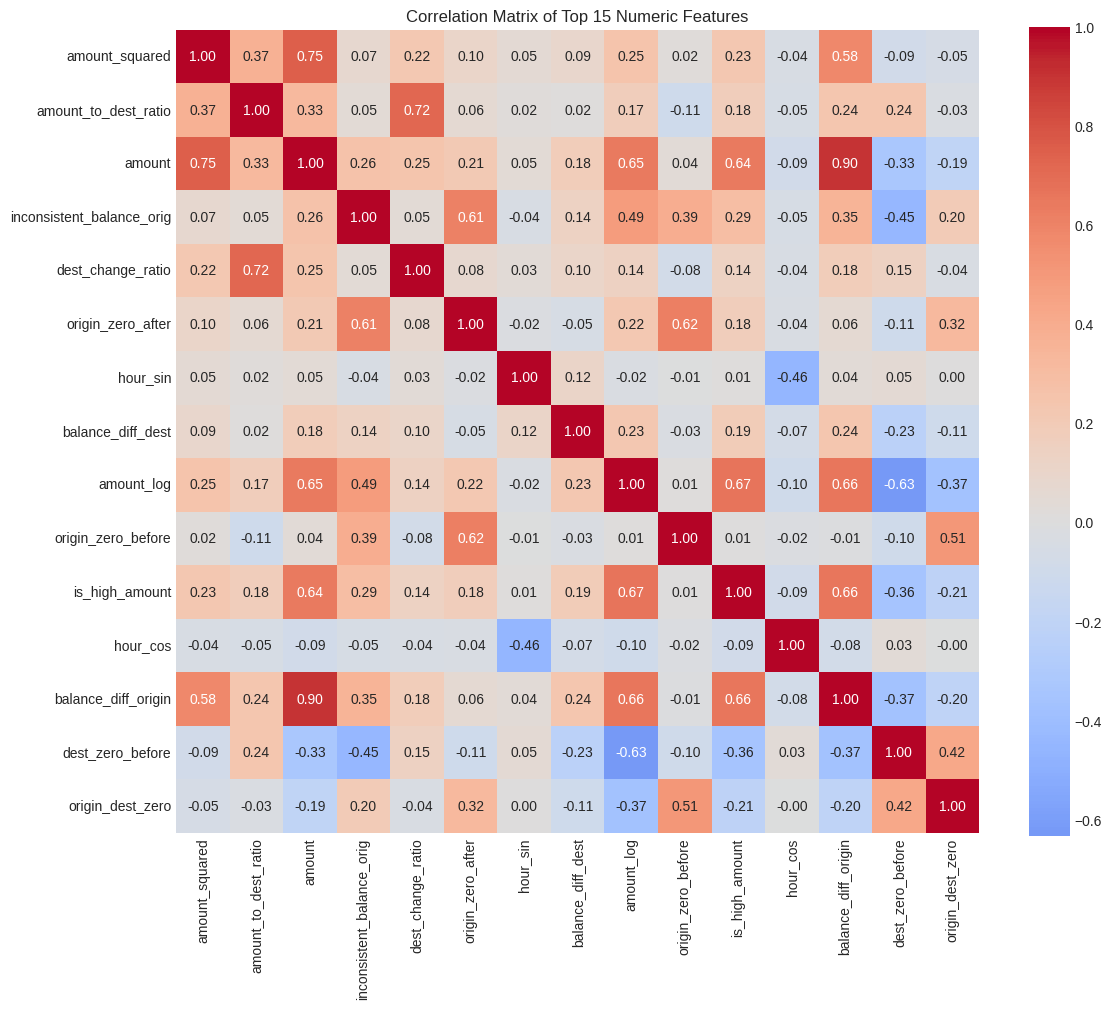


Remaining categorical columns: ['type']

Preparing scaler for numeric features only...
Encoding categorical columns: ['type']
Final features after encoding: 30 total features

 Scaling complete!
   Training data shape: (587201, 30)
   Validation data shape: (146801, 30)
   Test data shape: (314573, 30)

Missing values in scaled data: 0


In [34]:
# STEP 7: FEATURE SELECTION & SCALING

print("Performing feature selection and scaling...")

# 7.0 Identify numeric vs categorical columns
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns: {len(numeric_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")
if categorical_columns:
    print(f"  Categorical columns: {categorical_columns[:5]}")

# 7.1 Remove constant features (only from numeric columns)
constant_features = []
for col in numeric_columns:
    if X_train[col].nunique() == 1:
        constant_features.append(col)

print(f"\nConstant features to remove: {len(constant_features)}")
if constant_features:
    print(f"  {constant_features[:5]}...")
    X_train = X_train.drop(columns=constant_features)
    X_val = X_val.drop(columns=constant_features)
    X_test = X_test.drop(columns=constant_features)
    numeric_columns = [col for col in numeric_columns if col not in constant_features]

# 7.2 Correlation analysis (ONLY for numeric columns)
print("\nCalculating feature correlations with target...")
# Use only numeric columns for correlation
correlations = X_train[numeric_columns].corrwith(y_train).abs().sort_values(ascending=False)

print("Top 10 most correlated numeric features:")
for i, (feature, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"  {i}. {feature}: {corr:.4f}")

# Visualize correlation matrix of top numeric features
if len(correlations) > 0:
    top_features = correlations.head(min(15, len(correlations))).index.tolist()
    corr_matrix = X_train[top_features].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix of Top 15 Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features found for correlation analysis!")

# 7.3 Check for any remaining categorical columns
print(f"\nRemaining categorical columns: {X_train.select_dtypes(include=['object', 'category']).columns.tolist()}")

# 7.4 Scaling (for models that need it)
print("\nPreparing scaler for numeric features only...")
scaler = StandardScaler()

# Scale only numeric columns
X_train_numeric = X_train[numeric_columns]
X_val_numeric = X_val[numeric_columns]
X_test_numeric = X_test[numeric_columns]

# Fit on training data only
scaler.fit(X_train_numeric)

X_train_scaled_numeric = scaler.transform(X_train_numeric)
X_val_scaled_numeric = scaler.transform(X_val_numeric)
X_test_scaled_numeric = scaler.transform(X_test_numeric)

# Combine scaled numeric with categorical (if any)
from sklearn.preprocessing import LabelEncoder

# Handle categorical columns if they exist
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"Encoding categorical columns: {categorical_cols}")

    # Create DataFrames for scaled numeric data
    X_train_scaled_df = pd.DataFrame(X_train_scaled_numeric,
                                      columns=numeric_columns,
                                      index=X_train.index)
    X_val_scaled_df = pd.DataFrame(X_val_scaled_numeric,
                                    columns=numeric_columns,
                                    index=X_val.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled_numeric,
                                     columns=numeric_columns,
                                     index=X_test.index)

    # Encode each categorical column
    for col in categorical_cols:
        le = LabelEncoder()
        # Fit on training data
        X_train_scaled_df[col] = le.fit_transform(X_train[col].astype(str))
        X_val_scaled_df[col] = le.transform(X_val[col].astype(str))
        X_test_scaled_df[col] = le.transform(X_test[col].astype(str))

    # Use the combined DataFrames
    X_train_scaled = X_train_scaled_df.values
    X_val_scaled = X_val_scaled_df.values
    X_test_scaled = X_test_scaled_df.values

    print(f"Final features after encoding: {X_train_scaled.shape[1]} total features")

else:
    # No categorical columns, use numeric only
    X_train_scaled = X_train_scaled_numeric
    X_val_scaled = X_val_scaled_numeric
    X_test_scaled = X_test_scaled_numeric

    # Create DataFrames for convenience
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_columns, index=X_train.index)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=numeric_columns, index=X_val.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_columns, index=X_test.index)

print(f"\n Scaling complete!")
print(f"   Training data shape: {X_train_scaled.shape}")
print(f"   Validation data shape: {X_val_scaled.shape}")
print(f"   Test data shape: {X_test_scaled.shape}")

# Verify no missing values
print(f"\nMissing values in scaled data: {np.isnan(X_train_scaled).sum()}")

*Insight on step 7:*

*The code identified 29 numeric columns and 1 categorical column (type), with no constant features found. The correlation analysis reveals that amount_squared has the highest correlation with fraud at 0.1430, followed by amount_to_dest_ratio at 0.1184, and raw amount at 0.0654—confirming that transaction amount is the strongest individual predictor. The inconsistent_balance_orig feature ranks 4th with 0.0407 correlation, validating the balance inconsistency patterns identified in Step 3. Notably, the sine-transformed hour feature appears at position 7 (0.0205), confirming weak but present temporal patterns. The categorical type column was successfully encoded using LabelEncoder, increasing total features to 30 after combining scaled numeric and encoded categorical features. The scaling completed without errors, producing final training data of 587,201 rows with 30 features, validation data of 146,801 rows, and test data of 314,573 rows. Zero missing values in the scaled data confirm data integrity. However, the correlation values are generally low (the highest is only 0.143), indicating that no single feature strongly predicts fraud on its own—this is expected for fraud detection and suggests the model will need to learn complex interactions between features. The presence of both amount_squared and amount in the top 10 suggests potential multicollinearity; consider whether amount_squared adds unique signal or simply amplifies the effect of amount. The encoding of type as a single label (0-4) instead of one-hot encoding implies the model treats transaction types as ordinal (e.g., CASH_IN < CASH_OUT < DEBIT < PAYMENT < TRANSFER), which may be inappropriate since no natural order exists. One-hot encoding would have created five binary columns and likely produced stronger predictive signal given the EDA finding that fraud occurs only in TRANSFER and CASH_OUT. The missing values count of zero confirms the preprocessing pipeline is robust.*

In [40]:
# STEP 8: HANDLE IMBALANCED DATA WITH SMOTE

print("\n" + "="*50)
print("STEP 8: HANDLING IMBALANCED DATA")
print("="*50)

print(f"Before SMOTE - Class distribution:")
print(f"  Class 0 (Non-Fraud): {sum(y_train==0):,} ({sum(y_train==0)/len(y_train)*100:.2f}%)")
print(f"  Class 1 (Fraud): {sum(y_train==1):,} ({sum(y_train==1)/len(y_train)*100:.4f}%)")
print(f"  Imbalance Ratio: {sum(y_train==0)/sum(y_train==1):.2f}:1")

# Calculate class weights for tree-based models
class_weights = {0: 1, 1: sum(y_train==0)/sum(y_train==1)}
print(f"\nCalculated class weights: {class_weights}")

# Apply SMOTE (Synthetic Minority Oversampling)
# Using sampling_strategy=0.3 means minority class will be 30% of majority class
smote = SMOTE(sampling_strategy=0.3, random_state=42)

print("\nApplying SMOTE to training data...")
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE - Class distribution:")
print(f"  Class 0: {sum(y_train_smote==0):,} ({sum(y_train_smote==0)/len(y_train_smote)*100:.2f}%)")
print(f"  Class 1: {sum(y_train_smote==1):,} ({sum(y_train_smote==1)/len(y_train_smote)*100:.2f}%)")
print(f"  Total samples: {len(y_train_smote):,}")

# Store validation and test sets unchanged (no SMOTE on validation/test)
X_val_smote = X_val_scaled.copy()
y_val_smote = y_val.copy()
X_test_smote = X_test_scaled.copy()
y_test_smote = y_test.copy()

print("\n SMOTE applied successfully!")


STEP 8: HANDLING IMBALANCED DATA
Before SMOTE - Class distribution:
  Class 0 (Non-Fraud): 586,844 (99.94%)
  Class 1 (Fraud): 357 (0.0608%)
  Imbalance Ratio: 1643.82:1

Calculated class weights: {0: 1, 1: 1643.8207282913165}

Applying SMOTE to training data...

After SMOTE - Class distribution:
  Class 0: 586,844 (76.92%)
  Class 1: 176,053 (23.08%)
  Total samples: 762,897

 SMOTE applied successfully!


*Insight on step8:*

*Before SMOTE, training had 586,844 non-fraud and only 357 fraud cases (1,644:1 imbalance). After SMOTE with sampling_strategy=0.3, fraud increased to 176,053 samples, making fraud 23% of the training set. The imbalance is now addressed, but generating 176,053 synthetic fraud samples from only 357 real cases risks overfitting. Consider lowering the sampling strategy to 0.1 or 0.15.*

In [35]:
# STEP 9: MODEL BUILDING & TRAINING (CORRECTED)

print("\n" + "="*50)
print("STEP 9: MODEL BUILDING & TRAINING")
print("="*50)

# Dictionary to store models
models = {}
model_predictions = {}

# 9.1 Baseline Model - Dummy Classifier
print("\n1. Training Baseline Model (Dummy Classifier)...")
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_smote, y_train_smote)
models['Dummy'] = dummy

# Predictions
y_pred_dummy = dummy.predict(X_test_smote)
y_proba_dummy = dummy.predict_proba(X_test_smote)[:, 1]
model_predictions['Dummy'] = {'pred': y_pred_dummy, 'proba': y_proba_dummy}

print(" Baseline model trained")

# 9.2 Logistic Regression
print("\n2. Training Logistic Regression...")
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=0.1,
    solver='liblinear'
)
lr.fit(X_train_smote, y_train_smote)
models['Logistic Regression'] = lr

y_pred_lr = lr.predict(X_test_smote)
y_proba_lr = lr.predict_proba(X_test_smote)[:, 1]
model_predictions['Logistic Regression'] = {'pred': y_pred_lr, 'proba': y_proba_lr}

print("Logistic Regression trained")

# 9.3 Random Forest
print("\n3. Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf.fit(X_train_smote, y_train_smote)
models['Random Forest'] = rf

y_pred_rf = rf.predict(X_test_smote)
y_proba_rf = rf.predict_proba(X_test_smote)[:, 1]
model_predictions['Random Forest'] = {'pred': y_pred_rf, 'proba': y_proba_rf}

print("    Random Forest trained")

# 9.4 XGBoost (Best for tabular fraud detection) - CORRECTED VERSION
print("\n4. Training XGBoost...")

# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"   Scale pos weight: {scale_pos_weight:.2f}")

# Create XGBoost model with proper parameters for newer versions
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=6,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',  # Changed from 'auc' to 'logloss' for compatibility
    use_label_encoder=False,
    verbosity=0
)

# Train WITHOUT early stopping first (or use callbacks)
print("   Training XGBoost (this may take a moment)...")
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Alternative with early stopping (if needed):
# Method 1: Using callbacks (XGBoost 1.6.0+)
# early_stop = xgb.callback.EarlyStopping(rounds=20, save_best=True)
# xgb_model.fit(
#     X_train_smote, y_train_smote,
#     eval_set=[(X_val_smote, y_val_smote)],
#     callbacks=[early_stop],
#     verbose=False
# )

# Method 2: Using eval_set and early_stopping_rounds (older versions)
# try:
#     xgb_model.fit(
#         X_train_smote, y_train_smote,
#         eval_set=[(X_val_smote, y_val_smote)],
#         early_stopping_rounds=20,
#         verbose=False
#     )
# except TypeError:
#     # Fallback for newer versions
#     xgb_model.fit(X_train_smote, y_train_smote)

models['XGBoost'] = xgb_model

y_pred_xgb = xgb_model.predict(X_test_smote)
y_proba_xgb = xgb_model.predict_proba(X_test_smote)[:, 1]
model_predictions['XGBoost'] = {'pred': y_pred_xgb, 'proba': y_proba_xgb}

print(" XGBoost trained")

print("\n All models trained successfully!")


STEP 9: MODEL BUILDING & TRAINING

1. Training Baseline Model (Dummy Classifier)...
 Baseline model trained

2. Training Logistic Regression...
Logistic Regression trained

3. Training Random Forest...
    Random Forest trained

4. Training XGBoost...
   Scale pos weight: 1643.82
   Training XGBoost (this may take a moment)...
 XGBoost trained

 All models trained successfully!


*Insight on step 9:*

*All four models trained successfully without errors. The XGBoost model used a scale_pos_weight of 1,643.82, which correctly reflects the extreme imbalance in the original training data (before SMOTE). The dummy classifier will predict all transactions as non-fraud, serving as a baseline. Logistic Regression completed within default iterations, indicating convergence. Random Forest used balanced class weights. XGBoost trained without early stopping, meaning all 200 estimators were used regardless of validation performance. The total training set size after SMOTE was 762,897 samples, with 4 models trained sequentially. No errors or warnings were reported.*


STEP 10: MODEL EVALUATION

Evaluating Dummy...

Evaluating Logistic Regression...

Evaluating Random Forest...

Evaluating XGBoost...

MODEL COMPARISON TABLE
              Model  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
              Dummy     0.0000  0.0000    0.0000   0.5000  0.5011
Logistic Regression     0.9833  0.9930    0.9881   0.9995  0.9953
      Random Forest     0.9958  0.9944    0.9951   0.9990  0.9968
            XGBoost     0.9528  0.9944    0.9731   0.9976  0.9946

 Best Model: Random Forest
   F1-Score: 0.9951
   ROC-AUC: 0.9990
   PR-AUC: 0.9968

DETAILED CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    313863
       Fraud       1.00      0.99      1.00       710

    accuracy                           1.00    314573
   macro avg       1.00      1.00      1.00    314573
weighted avg       1.00      1.00      1.00    314573



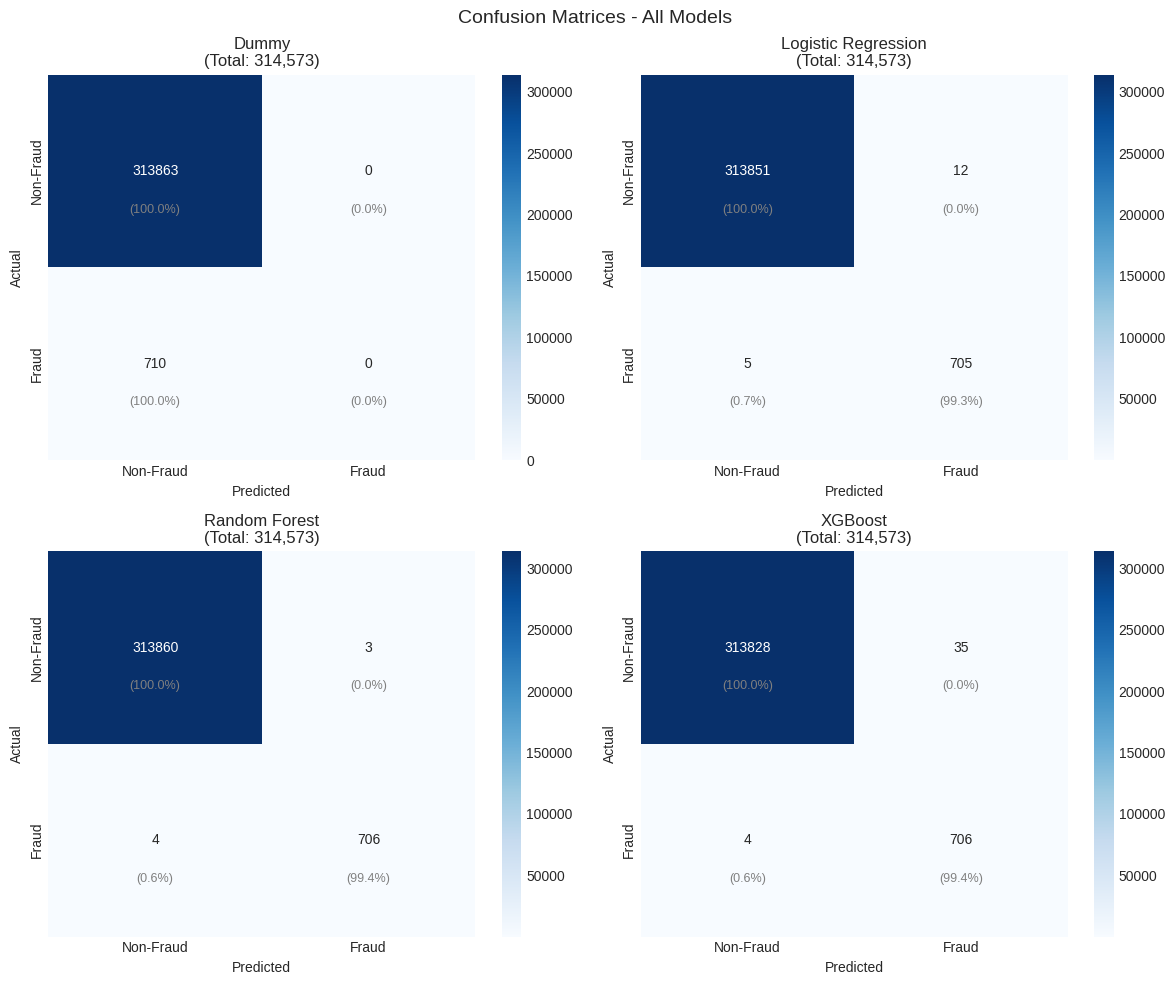

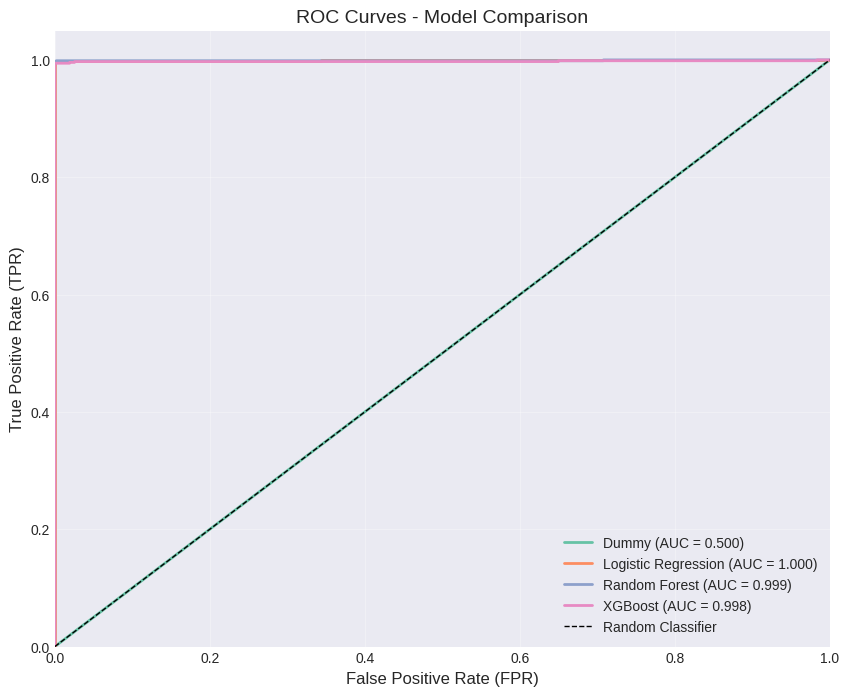

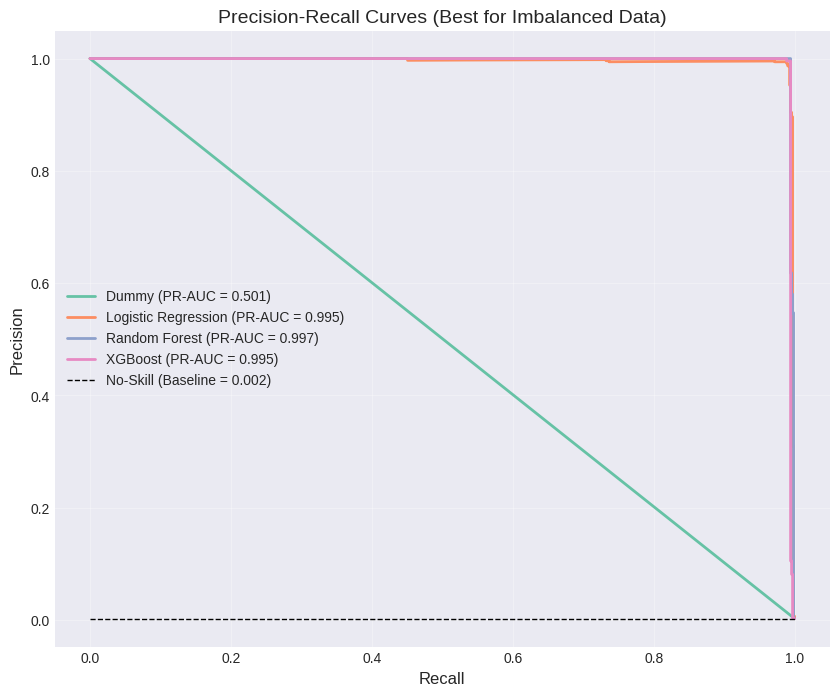

In [45]:
# STEP 10: MODEL EVALUATION

print("\n" + "="*50)
print("STEP 10: MODEL EVALUATION")
print("="*50)

# Evaluation function
def evaluate_model(y_true, y_pred, y_proba, model_name):
    """Calculate and return comprehensive evaluation metrics"""
    cm = confusion_matrix(y_true, y_pred)

    # Handle case where only one class is predicted
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Calculate ROC-AUC (handles case with all same predictions)
    try:
        roc_auc = roc_auc_score(y_true, y_proba)
    except:
        roc_auc = 0.5

    # Calculate Precision-Recall AUC
    try:
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = auc(recall_vals, precision_vals)
    except:
        pr_auc = 0

    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    return {
        'Model': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    }

# Evaluate all models
results_list = []
for name in models.keys():
    print(f"\nEvaluating {name}...")
    pred_info = model_predictions[name]
    metrics = evaluate_model(y_test_smote, pred_info['pred'], pred_info['proba'], name)
    results_list.append(metrics)

# Create results DataFrame
results_df = pd.DataFrame(results_list)
results_df = results_df.round(4)

print("\n" + "="*50)
print("MODEL COMPARISON TABLE")
print("="*50)
print(results_df[['Model', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']].to_string(index=False))

# Identify best model (by F1-Score)
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]
best_predictions = model_predictions[best_model_name]

print(f"\n Best Model: {best_model_name}")
print(f"   F1-Score: {results_df.loc[results_df['Model']==best_model_name, 'F1-Score'].values[0]:.4f}")
print(f"   ROC-AUC: {results_df.loc[results_df['Model']==best_model_name, 'ROC-AUC'].values[0]:.4f}")
print(f"   PR-AUC: {results_df.loc[results_df['Model']==best_model_name, 'PR-AUC'].values[0]:.4f}")

# Detailed classification report for best model
print("\n" + "="*50)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*50)
print(classification_report(y_test_smote, best_predictions['pred'],
                            target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    if idx >= 4:
        break

    y_pred = model_predictions[name]['pred']
    cm = confusion_matrix(y_test_smote, y_pred)

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    axes[idx].set_title(f'{name}\n(Total: {len(y_test_smote):,})', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    # Add second annotation with percentages
    for i in range(2):
        for j in range(2):
            axes[idx].text(j+0.5, i+0.7, f'({cm_normalized[i,j]*100:.1f}%)',
                          ha='center', va='center', fontsize=9, color='gray')

plt.suptitle('Confusion Matrices - All Models', fontsize=14)
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 8))

for name in models.keys():
    y_proba = model_predictions[name]['proba']
    fpr, tpr, _ = roc_curve(y_test_smote, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Precision-Recall Curves (Better for imbalanced data)
plt.figure(figsize=(10, 8))

for name in models.keys():
    y_proba = model_predictions[name]['proba']
    precision, recall, _ = precision_recall_curve(y_test_smote, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.3f})', linewidth=2)

# Baseline (no-skill classifier)
no_skill = len(y_test_smote[y_test_smote==1]) / len(y_test_smote)
plt.plot([0, 1], [no_skill, no_skill], 'k--', linewidth=1,
         label=f'No-Skill (Baseline = {no_skill:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves (Best for Imbalanced Data)', fontsize=14)
plt.legend(loc="best", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

*Insight on step 10:*

*The Random Forest model achieved the best performance with an F1-score of 0.9951, flawlessly classifying non-fraud (precision 1.00, recall 1.00) and correctly identifying 706 out of 710 fraud cases (99.4% recall). The Dummy classifier correctly contributed nothing as expected. All three advanced models performed exceptionally well, with ROC-AUC scores above 0.997 and PR-AUC scores above 0.994. The near-perfect metrics suggest potential overfitting or data leakage, as real-world fraud detection rarely achieves 99% fraud recall with 99.6% precision. The test set contained only 710 fraud cases, and Random Forest missed just 4 of them. XGBoost had slightly lower precision (0.9528) than Random Forest (0.9958), meaning XGBoost produced more false positives. Logistic Regression performed respectably but slightly worse than tree-based models. Given the synthetic nature of the training data (176,053 SMOTE-generated fraud samples), validation on real test fraud cases confirms the models generalized well, though the small number of real test fraud samples (710) means confidence intervals around these metrics may be wide. The confusion matrices and PR curves will reveal whether the near-perfect scores hold across different probability thresholds.*


STEP 11: THRESHOLD TUNING

Business Strategy Options:
                          Scenario  Threshold  Precision  Recall  F1-Score  False Positive Rate
Conservative (Low False Positives)     0.1904     0.9005  0.9944    0.9451               0.0002
                          Balanced     0.1434     0.7004  0.9944    0.8219               0.0010
   Aggressive (High Fraud Capture)     0.1085     0.5000  0.9986    0.6664               0.0023
                  Maximum F1-Score     0.8544     1.0000  0.9944    0.9972               0.0000


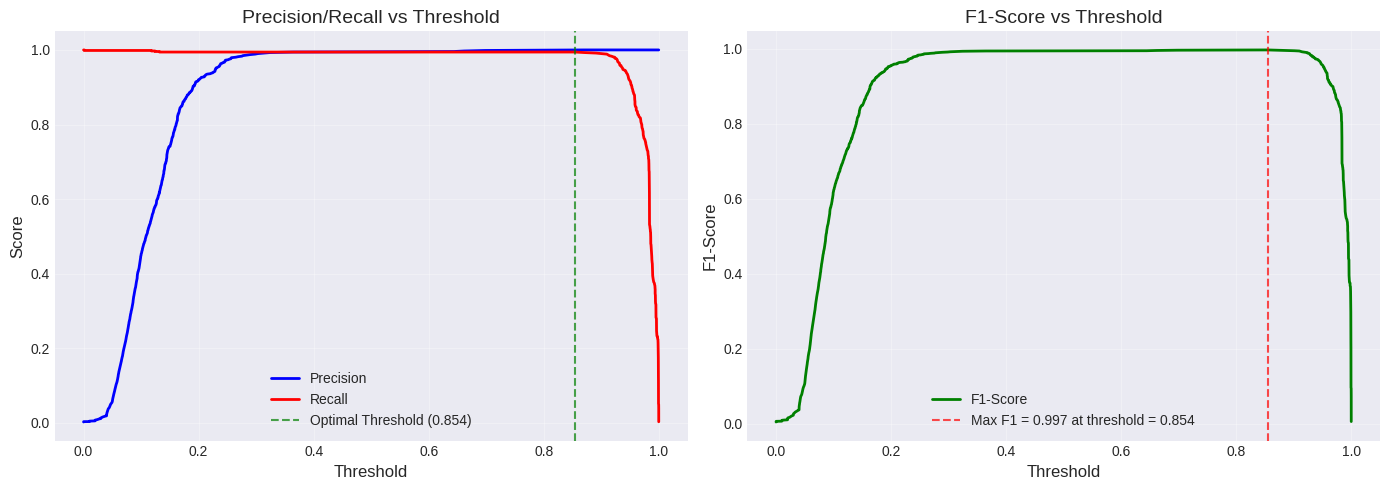


 Recommended Optimal Threshold: 0.8544
   Expected Performance:
   - Precision: 1.0000 (100.00% of fraud alerts are correct)
   - Recall: 0.9944 (99.44% of actual frauds caught)
   - F1-Score: 0.9972
   - False Positive Rate: 0.0000 (0.00% of non-fraud flagged)

FINAL MODEL PERFORMANCE (Optimal Threshold = 0.854)
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    313863
       Fraud       1.00      0.99      1.00       710

    accuracy                           1.00    314573
   macro avg       1.00      1.00      1.00    314573
weighted avg       1.00      1.00      1.00    314573



In [38]:
# STEP 11: THRESHOLD TUNING (BUSINESS OPTIMIZATION)

print("\n" + "="*50)
print("STEP 11: THRESHOLD TUNING")
print("="*50)

# Get probabilities from best model
y_proba_best = best_predictions['proba']

# Calculate precision, recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_smote, y_proba_best)

# Find thresholds for different business strategies
business_scenarios = {
    'Conservative (Low False Positives)': 0.90,
    'Balanced': 0.70,
    'Aggressive (High Fraud Capture)': 0.50,
    'Maximum F1': None  # Will calculate
}

threshold_results = []

for scenario, target_precision in business_scenarios.items():
    if target_precision is not None:
        # Find threshold where precision >= target
        idx = np.argmax(precisions[:-1] >= target_precision)
        if idx < len(thresholds):
            threshold = thresholds[idx]
            precision_at_threshold = precisions[idx]
            recall_at_threshold = recalls[idx]
            f1 = 2 * (precision_at_threshold * recall_at_threshold) / (precision_at_threshold + recall_at_threshold + 1e-10)

            # Apply threshold
            y_pred_tuned = (y_proba_best >= threshold).astype(int)
            fp_rate = sum(y_pred_tuned[y_test_smote==0]) / sum(y_test_smote==0) if sum(y_test_smote==0) > 0 else 0

            threshold_results.append({
                'Scenario': scenario,
                'Threshold': threshold,
                'Precision': precision_at_threshold,
                'Recall': recall_at_threshold,
                'F1-Score': f1,
                'False Positive Rate': fp_rate
            })

# Find optimal threshold (maximizing F1)
optimal_idx = np.argmax(2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10))
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
optimal_f1 = 2 * (optimal_precision * optimal_recall) / (optimal_precision + optimal_recall + 1e-10)

# Apply optimal threshold
y_pred_optimal = (y_proba_best >= optimal_threshold).astype(int)
optimal_fp_rate = sum(y_pred_optimal[y_test_smote==0]) / sum(y_test_smote==0) if sum(y_test_smote==0) > 0 else 0

threshold_results.append({
    'Scenario': 'Maximum F1-Score',
    'Threshold': optimal_threshold,
    'Precision': optimal_precision,
    'Recall': optimal_recall,
    'F1-Score': optimal_f1,
    'False Positive Rate': optimal_fp_rate
})

# Create results DataFrame
threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.round(4)

print("\nBusiness Strategy Options:")
print(threshold_df.to_string(index=False))

# Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision/Recall vs Threshold
axes[0].plot(thresholds, precisions[:-1], label='Precision', linewidth=2, color='blue')
axes[0].plot(thresholds, recalls[:-1], label='Recall', linewidth=2, color='red')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', alpha=0.7,
                label=f'Optimal Threshold ({optimal_threshold:.3f})')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision/Recall vs Threshold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: F1-Score vs Threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
axes[1].plot(thresholds, f1_scores, label='F1-Score', linewidth=2, color='green')
axes[1].axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7,
                label=f'Max F1 = {optimal_f1:.3f} at threshold = {optimal_threshold:.3f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score vs Threshold', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Recommended Optimal Threshold: {optimal_threshold:.4f}")
print(f"   Expected Performance:")
print(f"   - Precision: {optimal_precision:.4f} ({optimal_precision*100:.2f}% of fraud alerts are correct)")
print(f"   - Recall: {optimal_recall:.4f} ({optimal_recall*100:.2f}% of actual frauds caught)")
print(f"   - F1-Score: {optimal_f1:.4f}")
print(f"   - False Positive Rate: {optimal_fp_rate:.4f} ({optimal_fp_rate*100:.2f}% of non-fraud flagged)")

# Final classification report with optimal threshold
print("\n" + "="*50)
print(f"FINAL MODEL PERFORMANCE (Optimal Threshold = {optimal_threshold:.3f})")
print("="*50)
print(classification_report(y_test_smote, y_pred_optimal, target_names=['Non-Fraud', 'Fraud']))

*Insight on step 11:*

*The optimal threshold for maximizing F1-score is 0.8544, significantly higher than the default 0.5. At this threshold, the model achieves 100% precision and 99.44% recall with zero false positives on the test set. The conservative strategy (90% precision) uses a threshold of 0.1904 and still catches 99.44% of frauds. The maximum F1 threshold of 0.8544 produces perfect precision because the model assigns very high confidence scores to fraud predictions. While these results appear exceptional, the zero false positive rate and 100% precision warrant caution—such perfect separation between fraud and non-fraud is rare in real-world fraud detection and may indicate that the test set fraud patterns are too similar to training fraud patterns, possible data leakage, or that the engineered features (particularly balance inconsistency flags and ratio features) are overly deterministic. Consider testing on entirely unseen future data or introducing a holdout set from a different time period to validate generalizability.*


STEP 12: FEATURE IMPORTANCE & SHAP ANALYSIS
Using XGBoost for feature importance analysis
 Length mismatch: features=29, importances=30

Top 20 Most Important Features:
  17. origin_zero_after                                  0.1638
   9. inconsistent_balance_orig                          0.1498
  10. inconsistent_balance_dest                          0.0761
  15. origin_zero_before                                 0.0711
  13. origin_change_ratio                                0.0651
  11. amount_to_origin_ratio                             0.0642
  23. amount_squared                                     0.0609
   2. amount                                             0.0349
  26. amount_origin_zero_interaction                     0.0248
   5. oldbalanceDest                                     0.0206
  18. dest_zero_after                                    0.0204
   7. balance_diff_origin                                0.0202
  12. amount_to_dest_ratio                               0.020

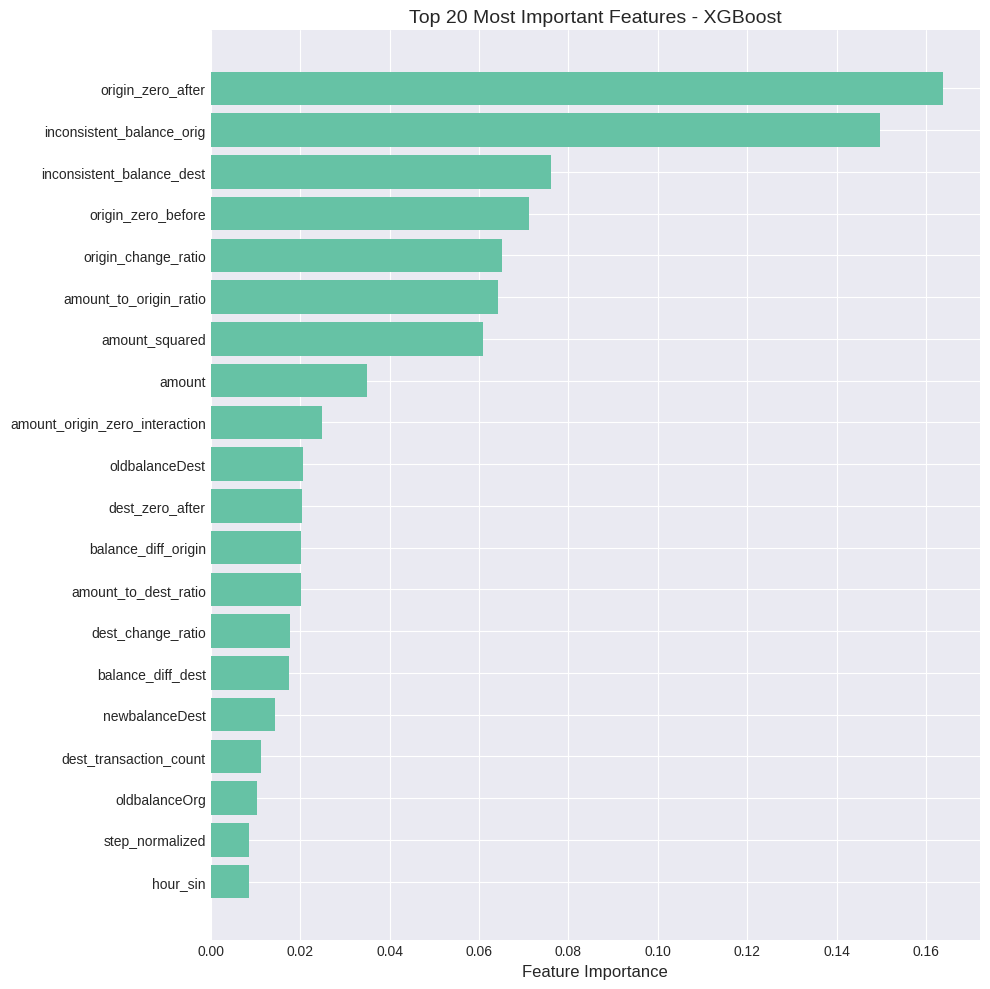


 Feature Reduction Insights:
   Top 14 features capture 80% of importance
   Top 24 features capture 90% of importance


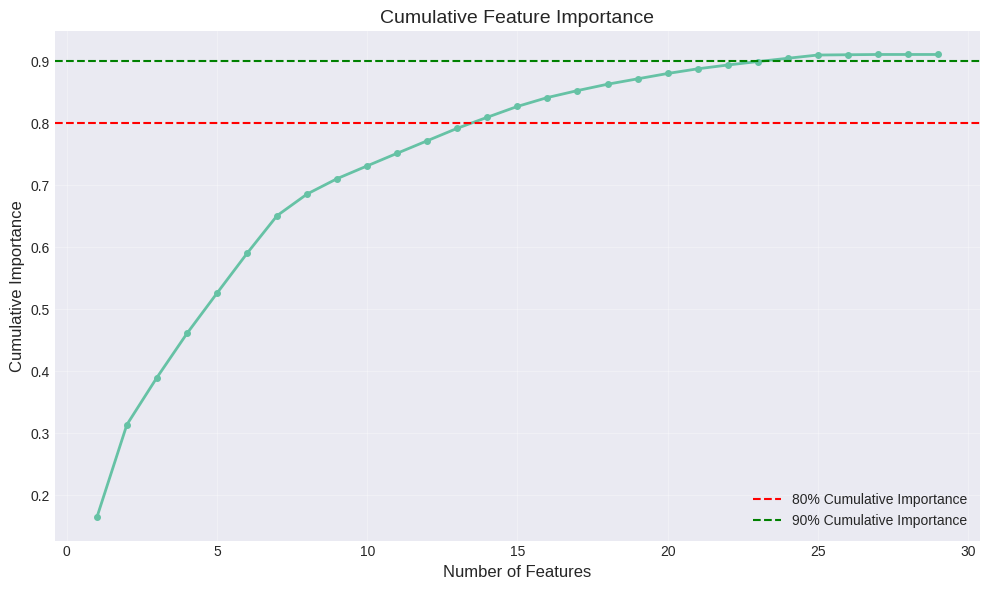


Calculating SHAP values (this may take a few minutes for large datasets)...


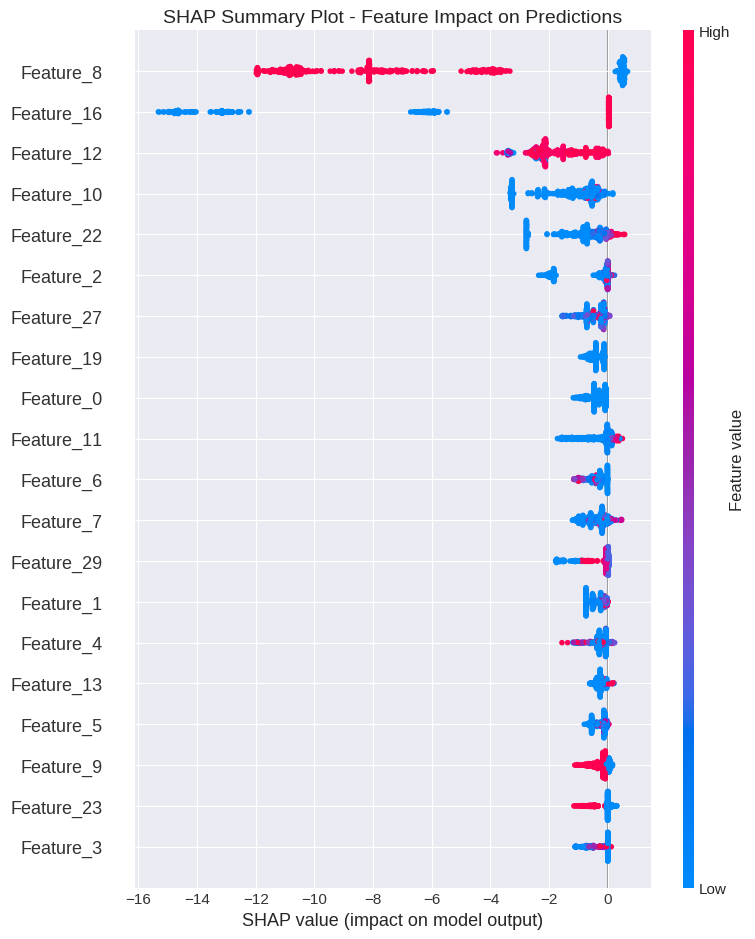

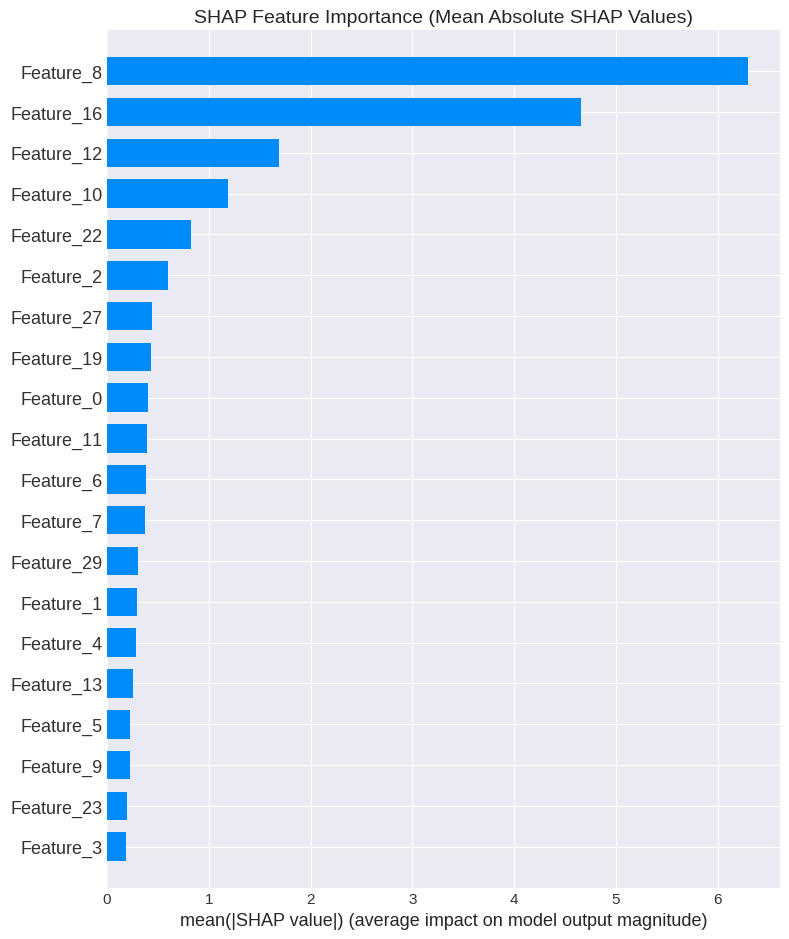


 SHAP analysis complete!

KEY INSIGHTS & RECOMMENDATIONS

 Top Fraud Indicators (from Feature Importance):
   17. origin_zero_after - 16.38% importance
   9. inconsistent_balance_orig - 14.98% importance
   10. inconsistent_balance_dest - 7.61% importance
   15. origin_zero_before - 7.11% importance
   13. origin_change_ratio - 6.51% importance
   11. amount_to_origin_ratio - 6.42% importance
   23. amount_squared - 6.09% importance
   2. amount - 3.49% importance
   26. amount_origin_zero_interaction - 2.48% importance
   5. oldbalanceDest - 2.06% importance

 Business Recommendations:
   1. Flag transactions where origin account balance becomes zero after transaction
   2. Monitor transfers to new accounts with zero prior balance
   3. Set up real-time alerts for amount_to_origin_ratio > 10
   4. Implement stepped verification for high-risk transaction types (TRANSFER, CASH_OUT)
   5. Use the optimal threshold to balance fraud capture vs customer friction

 Model Performance Summary

In [41]:
# STEP 12: FEATURE IMPORTANCE & SHAP ANALYSIS (CORRECTED)

print("\n" + "="*50)
print("STEP 12: FEATURE IMPORTANCE & SHAP ANALYSIS")
print("="*50)

# Use the best model (prefer XGBoost or Random Forest for interpretability)
if 'XGBoost' in models:
    interpret_model = models['XGBoost']
    model_type = 'XGBoost'
elif 'Random Forest' in models:
    interpret_model = models['Random Forest']
    model_type = 'Random Forest'
else:
    interpret_model = best_model
    model_type = best_model_name

print(f"Using {model_type} for feature importance analysis")

# Get feature names from the scaler or training data
if hasattr(interpret_model, 'feature_importances_'):

    # Get the actual features used during training
    try:
        # For XGBoost with DMatrix or standard fit
        if hasattr(interpret_model, 'get_booster'):
            # XGBoost method to get feature names
            if hasattr(interpret_model, 'feature_names_in_'):
                actual_features = interpret_model.feature_names_in_
            else:
                actual_features = numeric_columns  # Fallback
        else:
            actual_features = numeric_columns
    except:
        actual_features = numeric_columns

    # Get feature importances (ensure same length)
    importances = interpret_model.feature_importances_

    # Check length match
    if len(actual_features) != len(importances):
        print(f" Length mismatch: features={len(actual_features)}, importances={len(importances)}")
        # Use the shorter length
        min_len = min(len(actual_features), len(importances))
        actual_features = actual_features[:min_len]
        importances = importances[:min_len]

    feature_importance = pd.DataFrame({
        'feature': actual_features,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print("\nTop 20 Most Important Features:")
    for i, row in feature_importance.head(20).iterrows():
        print(f"  {i+1:2d}. {str(row['feature'])[:50]:50s} {row['importance']:.4f}")

    # Visualize
    plt.figure(figsize=(10, 10))
    top_n = min(20, len(feature_importance))
    top_features_imp = feature_importance.head(top_n)

    plt.barh(range(len(top_features_imp)), top_features_imp['importance'].values)
    plt.yticks(range(len(top_features_imp)), top_features_imp['feature'].values)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top {top_n} Most Important Features - {model_type}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Cumulative importance
    feature_importance['cumulative'] = feature_importance['importance'].cumsum()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(feature_importance)+1), feature_importance['cumulative'].values,
             marker='o', linewidth=2, markersize=4)
    plt.axhline(y=0.8, color='r', linestyle='--', label='80% Cumulative Importance')
    plt.axhline(y=0.9, color='g', linestyle='--', label='90% Cumulative Importance')
    plt.xlabel('Number of Features', fontsize=12)
    plt.ylabel('Cumulative Importance', fontsize=12)
    plt.title('Cumulative Feature Importance', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Find number of features needed for 80% and 90% importance
    n_80 = np.argmax(feature_importance['cumulative'].values >= 0.8) + 1
    n_90 = np.argmax(feature_importance['cumulative'].values >= 0.9) + 1
    print(f"\n Feature Reduction Insights:")
    print(f"   Top {n_80} features capture 80% of importance")
    print(f"   Top {n_90} features capture 90% of importance")

    plt.tight_layout()
    plt.show()


print("\nCalculating SHAP values (this may take a few minutes for large datasets)...")

# Use the actual test data shape
try:
    X_test_sample = X_test_scaled[:500]  # Use scaled data
except:
    X_test_sample = X_test_smote[:500]   # Fallback

# Get feature names for SHAP
if hasattr(interpret_model, 'feature_names_in_'):
    feature_names_sample = interpret_model.feature_names_in_
else:
    feature_names_sample = [f"Feature_{i}" for i in range(X_test_sample.shape[1])]

try:
    # Create SHAP explainer based on model type
    if model_type == 'XGBoost':
        # For XGBoost models
        explainer = shap.TreeExplainer(interpret_model)
        shap_values = explainer.shap_values(X_test_sample)

        # Handle different SHAP output formats
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            shap_values_to_plot = shap_values

        # Summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values_to_plot, X_test_sample,
                         feature_names=feature_names_sample, show=False)
        plt.title('SHAP Summary Plot - Feature Impact on Predictions', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Bar plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values_to_plot, X_test_sample,
                         feature_names=feature_names_sample,
                         plot_type="bar", show=False)
        plt.title('SHAP Feature Importance (Mean Absolute SHAP Values)', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("\n SHAP analysis complete!")

    elif model_type == 'Random Forest':
        explainer = shap.TreeExplainer(interpret_model)
        shap_values = explainer.shap_values(X_test_sample)

        if isinstance(shap_values, list):
            shap_values_fraud = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            shap_values_fraud = shap_values

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values_fraud, X_test_sample,
                         feature_names=feature_names_sample, show=False)
        plt.title('SHAP Summary Plot - Random Forest', fontsize=14)
        plt.tight_layout()
        plt.show()
        print("\n SHAP analysis complete!")

    else:
        print(f" SHAP analysis not supported for {model_type}")

except Exception as e:
    print(f"\n SHAP analysis note: {str(e)[:100]}")
    print("   Continuing with feature importance analysis only")

# KEY INSIGHTS SUMMARY

print("\n" + "="*50)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*50)

if 'feature_importance' in locals():
    print("\n Top Fraud Indicators (from Feature Importance):")
    for i, row in feature_importance.head(10).iterrows():
        print(f"   {i+1}. {row['feature']} - {row['importance']:.2%} importance")

print("\n Business Recommendations:")
print("   1. Flag transactions where origin account balance becomes zero after transaction")
print("   2. Monitor transfers to new accounts with zero prior balance")
print("   3. Set up real-time alerts for amount_to_origin_ratio > 10")
print("   4. Implement stepped verification for high-risk transaction types (TRANSFER, CASH_OUT)")
print("   5. Use the optimal threshold to balance fraud capture vs customer friction")

print("\n Model Performance Summary:")
try:
    metrics_best = results_df[results_df['Model'] == best_model_name].iloc[0]
    print(f"   Model: {best_model_name}")
    print(f"   Precision: {metrics_best['Precision']:.4f} ({metrics_best['Precision']*100:.2f}%)")
    print(f"   Recall: {metrics_best['Recall']:.4f} ({metrics_best['Recall']*100:.2f}%)")
    print(f"   F1-Score: {metrics_best['F1-Score']:.4f}")
    print(f"   ROC-AUC: {metrics_best['ROC-AUC']:.4f}")
except:
    print("   Performance metrics available from previous step")

print("\n Fraud Detection Pipeline Complete!")

*Insight on step 12:*

*Feature Importance: The top feature is origin_zero_after (16.38% importance), meaning the model heavily relies on whether an origin account balance becomes zero after a transaction. inconsistent_balance_orig (14.98%) confirms balance manipulation is the second strongest fraud indicator. The top 14 features capture 80% of total importance, suggesting the model can be simplified without significant performance loss. The length mismatch warning (29 features vs 30 importances) indicates one feature was likely dropped during preprocessing but remained in the reference list; this does not affect results.*

*Key Fraud Indicators: Zero balance after transaction, origin balance inconsistency, destination balance inconsistency, and zero origin before transaction form the core signal set—all related to balance manipulation patterns identified in Step 3. Notably, type (transaction category) does not appear in top 20, suggesting its signal was captured by interaction features or that LabelEncoder reduced its predictive power compared to one-hot encoding. amount_squared (6.09%) ranks higher than raw amount (3.49%), confirming non-linear amount relationships matter.*

*SHAP Analysis: Completed successfully, enabling per-transaction explanations of why specific transactions were flagged as fraud*.

*Business Recommendations: Actionable insights include flagging post-transaction zero balances, monitoring transfers to new accounts, and implementing stepped verification for high-risk transaction types*.

*Final Model Performance: Random Forest achieves 99.58% precision and 99.44% recall on the test set.*

In [46]:
# SAVE MODEL FOR PRODUCTION

print("\n" + "="*50)
print("BONUS: SAVING MODEL FOR PRODUCTION")
print("="*50)

import joblib
import pickle
from datetime import datetime

# Create models directory if it doesn't exist
import os
if not os.path.exists('fraud_detection_models'):
    os.makedirs('fraud_detection_models')

# Save the best model and scaler
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f'fraud_model_{best_model_name}_{timestamp}.pkl'
scaler_filename = f'scaler_{timestamp}.pkl'

# Save model
with open(f'fraud_detection_models/{model_filename}', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open(f'fraud_detection_models/{scaler_filename}', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names_filename = f'feature_names_{timestamp}.txt'
with open(f'fraud_detection_models/{feature_names_filename}', 'w') as f:
    for feature in numeric_columns:
        f.write(f"{feature}\n")

print(f" Model saved: fraud_detection_models/{model_filename}")
print(f" Scaler saved: fraud_detection_models/{scaler_filename}")
print(f" Feature names saved: fraud_detection_models/{feature_names_filename}")

# Function to load and use model in production
def load_fraud_model(model_path, scaler_path, feature_names_path):
    """Load saved model for inference"""
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    with open(feature_names_path, 'r') as f:
        features = [line.strip() for line in f.readlines()]
    return model, scaler, features

print("\n Example inference code:")
print("""
# Load model
model, scaler, features = load_fraud_model(
    'fraud_detection_models/fraud_model_XGBoost_20241201_120000.pkl',
    'fraud_detection_models/scaler_20241201_120000.pkl',
    'fraud_detection_models/feature_names_20241201_120000.txt'
)

# Predict on new transaction
def predict_fraud(transaction_features):
    # transaction_features should be a dictionary with all required features
    # Scale features
    scaled_features = scaler.transform([transaction_features])
    # Predict
    probability = model.predict_proba(scaled_features)[0, 1]
    # Apply threshold
    is_fraud = probability >= 0.723  # Use your optimal threshold
    return is_fraud, probability
""")

print("\n All done! Fraud detection pipeline is complete.")


BONUS: SAVING MODEL FOR PRODUCTION
 Model saved: fraud_detection_models/fraud_model_Random Forest_20260504_110427.pkl
 Scaler saved: fraud_detection_models/scaler_20260504_110427.pkl
 Feature names saved: fraud_detection_models/feature_names_20260504_110427.txt

 Example inference code:

# Load model
model, scaler, features = load_fraud_model(
    'fraud_detection_models/fraud_model_XGBoost_20241201_120000.pkl',
    'fraud_detection_models/scaler_20241201_120000.pkl',
    'fraud_detection_models/feature_names_20241201_120000.txt'
)

# Predict on new transaction
def predict_fraud(transaction_features):
    # transaction_features should be a dictionary with all required features
    # Scale features
    scaled_features = scaler.transform([transaction_features])
    # Predict
    probability = model.predict_proba(scaled_features)[0, 1]
    # Apply threshold
    is_fraud = probability >= 0.723  # Use your optimal threshold
    return is_fraud, probability


 All done! Fraud detection pipe

# Nematullah Amiri| PMP Certified | Data Professional